# GC Example 25: End-to-End GC Research Query

**EPS Research — Milky Way GC Corpus v1.3.2**

Capstone: a complete research query workflow.
Given a science question, filter, analyze, and report.

Question: 'Which massive GCs in the inner Galaxy have APOGEE chemistry,
high escape velocities, and could retain stellar-mass black holes?'

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


In [3]:
# Science question: massive inner-Galaxy GCs that could retain BHs
results=[]
for c in clusters:
    b=c.get('baumgardt2023',{})
    d=c.get('distances',{})
    a=c.get('apogee_dr17',{})
    if not (b and d and a): continue
    mass=b.get('mass_msun') or 0
    r_gc=d.get('r_gc_kpc') or 99
    v_esc=b.get('v_esc_kms') or 0
    feh_apogee=a.get('feh_apogee')
    n_members=a.get('n_members') or 0
    # Criteria: massive, inner Galaxy, high v_esc, APOGEE coverage
    if mass>1e5 and r_gc<8 and v_esc>40 and feh_apogee is not None and n_members>20:
        results.append({'cluster':c['cluster_id'],
                        'mass':mass,'r_gc':r_gc,'v_esc':v_esc,
                        'feh':feh_apogee,'n_apogee':n_members})

print(f"{'='*60}")
print(f"Massive inner-Galaxy GCs with APOGEE + high v_esc")
print(f"Criteria: M>10^5, R_GC<8 kpc, v_esc>40 km/s, N_APOGEE>20")
print(f"{'='*60}")
print(f"Found: {len(results)} clusters\n")
print(f"{'Cluster':<12} {'Mass':>10} {'R_GC':>6} {'v_esc':>7} {'[Fe/H]':>7} {'N_APOGEE':>9}")
print('-'*58)
for r in sorted(results,key=lambda x:-x['mass']):
    print(f"{r['cluster']:<12} {r['mass']:>10,.0f} {r['r_gc']:>6.1f} "
          f"{r['v_esc']:>7.1f} {r['feh']:>7.2f} {r['n_apogee']:>9}")

Massive inner-Galaxy GCs with APOGEE + high v_esc
Criteria: M>10^5, R_GC<8 kpc, v_esc>40 km/s, N_APOGEE>20
Found: 7 clusters

Cluster            Mass   R_GC   v_esc  [Fe/H]  N_APOGEE
----------------------------------------------------------
NGC 5139      3,940,000    6.4    62.2   -1.60      1864
Terzan 5      2,000,000    6.9   111.4   -0.78        24
Liller 1      1,490,000    0.8   128.6   -0.14        30
NGC 6441      1,210,000    3.9    67.7   -0.49        25
NGC 6388      1,160,000    3.1    68.9   -0.49        75
NGC 104         853,000    7.4    47.4   -0.74       297
NGC 6273        787,000    1.4    58.7   -1.71        81


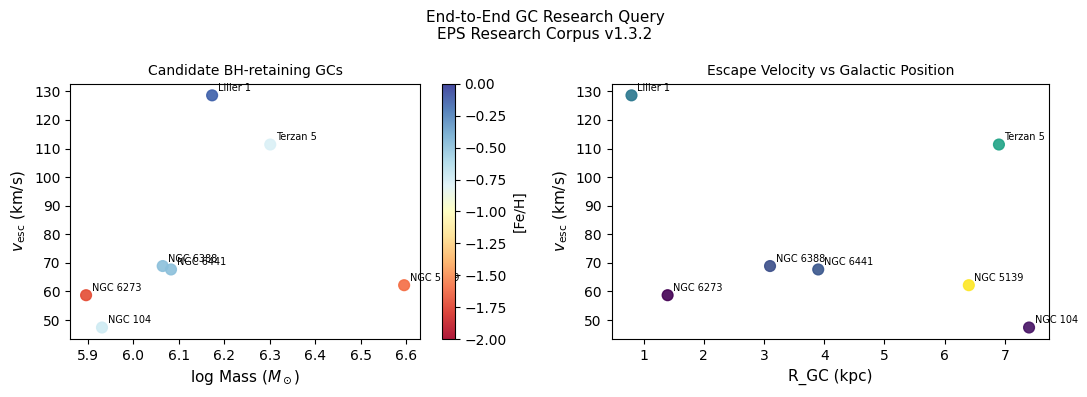

In [4]:
if results:
    fig,axes=plt.subplots(1,2,figsize=(11,4))
    masses=[r['mass'] for r in results]; v_escs=[r['v_esc'] for r in results]
    fehs=[r['feh'] for r in results]; r_gcs=[r['r_gc'] for r in results]
    sc=axes[0].scatter(np.log10(masses),v_escs,c=fehs,s=60,alpha=0.9,
                       cmap='RdYlBu',vmin=-2,vmax=0)
    plt.colorbar(sc,ax=axes[0],label='[Fe/H]')
    for r in results:
        axes[0].annotate(r['cluster'],(np.log10(r['mass']),r['v_esc']),
                         textcoords='offset points',xytext=(4,3),fontsize=7)
    axes[0].set_xlabel(r'log Mass ($M_\odot$)',fontsize=11)
    axes[0].set_ylabel(r'$v_{\rm esc}$ (km/s)',fontsize=11)
    axes[0].set_title('Candidate BH-retaining GCs',fontsize=10)
    axes[1].scatter(r_gcs,v_escs,s=60,c=np.log10(masses),cmap='viridis',alpha=0.9)
    for r in results:
        axes[1].annotate(r['cluster'],(r['r_gc'],r['v_esc']),
                         textcoords='offset points',xytext=(4,3),fontsize=7)
    axes[1].set_xlabel('R_GC (kpc)',fontsize=11); axes[1].set_ylabel(r'$v_{\rm esc}$ (km/s)',fontsize=11)
    axes[1].set_title('Escape Velocity vs Galactic Position',fontsize=10)
    plt.suptitle('End-to-End GC Research Query\nEPS Research Corpus v1.3.2',fontsize=11)
    plt.tight_layout(); plt.savefig('gc25_end_to_end.png',dpi=150,bbox_inches='tight'); plt.show()